# 2 · Preprocessing: from raw RSSI to model inputs

This notebook walks through Section IV of the paper one step at a time. Every function
used here is in `lora_loc/preprocessing.py`, so the models in notebook 3 see exactly the
same data.

| Step | Operation | Paper |
|---|---|---|
| 1 | keep the 44 active gateways | Sec. IV |
| 2 | replace −200 dBm (no reception) with −128 dBm | Sec. IV |
| 3 | $\hat x = \log_{10}(\lvert x\rvert+1)$ | Eq. 12 |
| 4 | min–max scale RSSI with **one global** min/max | Eq. 13 |
| 5 | min–max scale each extra feature (SF, …) **separately** | Eq. 14 |
| 6 | min–max scale latitude and longitude | Eq. 16 |
| 7 | 70 / 15 / 15 train / validation / test split | Sec. V |

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # make `lora_loc` importable from notebooks/
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lora_loc import config, data, preprocessing as pp, features, geo, plotting
plotting.style()
pd.set_option("display.precision", 2)

In [2]:
df = data.load_csv()
active = data.active_gateways(df)
X_raw = df[active].to_numpy(dtype=float)
print("raw RSSI matrix:", X_raw.shape)

raw RSSI matrix: (130429, 44)


## Step 2 — the "no signal" placeholder

The dataset uses −200 dBm for "not received". Passed to a model as is, the value creates a
huge artificial gap. Relative to the real range [−127, −60], "not heard" would look far more
different from "barely heard" (−127) than −127 looks from −60. That is physically wrong, because
a gateway that just missed a packet is almost the same observation as one that just caught it.
Following Bagherian et al., the paper replaces −200 with the **neighbouring value −128 dBm**.

In [3]:
X = pp.replace_no_signal(X_raw)
print("after replacement: min", X.min(), " max", X.max())
print(f"share of entries that are 'no signal': {(X_raw == -200).mean():.1%}")

after replacement: min -128.0  max -60.0
share of entries that are 'no signal': 93.7%


## Step 3 — logarithmic transform (Eq. 12)

$$\hat x_{\mathrm{RSSI},g} = \log_{10}\!\left(\lvert x_{\mathrm{RSSI},g}\rvert + 1\right),\qquad g=1,\dots,44 .$$

RSSI in dBm is already logarithmic in power. Taking the log again compresses the strong-signal
end relative to the weak end. Note the sign: because of $\lvert\cdot\rvert$, a **strong** signal
(−60 dBm) maps to a **small** value (1.785) and "no signal" (−128) maps to the largest value
(2.111). Tree models do not care about the direction, and neural networks learn the sign.

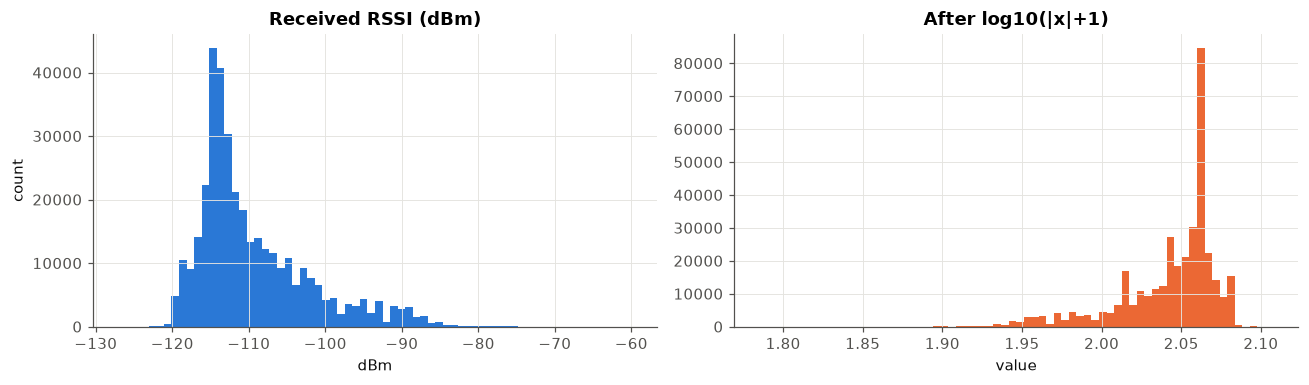

mapping: -60 dBm -> 1.7853   -128 dBm -> 2.1106


In [4]:
X_log = pp.log_transform(X)
received = X_raw != -200
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(X[received], bins=68, color=plotting.MODEL_COLORS["k-NN"])
ax[0].set(title="Received RSSI (dBm)", xlabel="dBm", ylabel="count")
ax[1].hist(X_log[received], bins=68, color=plotting.MODEL_COLORS["CNN"])
ax[1].set(title="After log10(|x|+1)", xlabel="value")
plt.tight_layout(); plt.show()
print("mapping: -60 dBm ->", pp.log_transform(-60.0).round(4), "  -128 dBm ->", pp.log_transform(-128.0).round(4))

## Steps 4–6 — min–max scaling

$$\bar x = \frac{\hat x - \min(\hat X)}{\max(\hat X) - \min(\hat X)} \in [0,1].$$

* **RSSI** uses **one** min and max over *all* gateways (Eq. 13 has no gateway subscript).
  This keeps relative levels across gateways, and the pattern of relative levels *is* the fingerprint.
  Per-gateway scaling would, for example, stretch a gateway that only ever sees −120…−110 dBm
  over the full [0, 1] range.
* **Other features** (SF, and for FV3–FV16 also channel, counter, airtime, SNR, ESP) are scaled
  column by column (Eq. 14).
* **Targets** are scaled per coordinate (Eq. 16), and predictions are mapped back to degrees
  before we measure errors in metres.

> **Leakage.** All scalers are fit on the **training split only** and then applied to validation
> and test. The paper does not say which it did. For RSSI it makes no difference, because the
> range is fixed at [−128, −60] after step 2.

In [5]:
d = pp.prepare(df, active)          # FV1: RSSI only
print("train / val / test:", len(d.X_train), len(d.X_val), len(d.X_test))
print("X range:", d.X_train.min(), "→", d.X_train.max(), "  features:", d.X_train.shape[1])
print("global RSSI scaler (log domain): min %.4f  max %.4f" % (d.pipeline.rssi_scaler.min_, d.pipeline.rssi_scaler.max_))
pd.DataFrame(d.y_train[:5], columns=["lat (scaled)", "lon (scaled)"])

train / val / test: 91300 19564 19565
X range: 0.0 → 1.0   features: 44
global RSSI scaler (log domain): min 1.8195  max 2.1106


,lat (scaled),lon (scaled)
0,0.59,0.70
1,0.36,0.46
2,0.34,0.59
3,0.44,0.53
4,0.96,0.66


## Step 7 — the split

`train_test_split` is applied twice with `random_state = 42`: first 70 % / 30 %, then the 30 %
is halved. This gives **91,300 / 19,564 / 19,565** samples, exactly the numbers in the paper,
which is good evidence that the split matches the authors'.

The split is **random per message**. Consecutive messages from the same vehicle, seconds apart,
can land in train and test. That favours methods that memorise, such as k-NN and deep trees.
It is the paper's protocol and we keep it. A split by time or by region would give a more
conservative estimate. Notebook 4 comes back to this.

## Feature vectors (Table 9)

In [6]:
fv = pd.DataFrame({k: ", ".join(v) for k, v in features.FEATURE_VECTORS.items()}, index=["features"]).T
fv["available from CSV"] = ["yes" if k in features.CSV_FEATURE_VECTORS else "JSON needed" for k in fv.index]
fv

,features,available from CSV
FV1,RSSI,yes
FV2,"RSSI, SF",yes
FV3,"RSSI, SF, CH",JSON needed
FV4,"RSSI, SF, CNT",JSON needed
FV5,"RSSI, SF, AT",JSON needed
FV6,"RSSI, SF, CH, CNT",JSON needed
FV7,"RSSI, SF, CH, CNT, AT",JSON needed
FV8,"RSSI, SF, CNT, AT",JSON needed
FV9,"RSSI, SNR",JSON needed
FV10,"RSSI, ESP",JSON needed


The CSV release has RSSI and SF only, so **FV1 and FV2** can be built from it. Channel (CH),
frame counter (CNT), airtime (AT), SNR and ESP are only in the JSON release. `lora_loc.data.load_json`
parses it (tested against the schema published on Zenodo), and notebook 4 runs FV3–FV16
automatically if `data/lorawan_antwerp_2019_dataset.json.txt` is present.

> **A caution about CNT (frame counter).** FV4, FV6–FV8, FV15 and FV16 contain the uplink
> counter and give the paper's best results (≈245–255 m versus ≈325 m for RSSI only). The counter
> is a device-specific, steadily increasing number. Together with a random per-message split, it
> lets a model find *temporally adjacent messages from the same vehicle* in the training set, and
> those were sent from almost the same place. The improvement may therefore reflect track
> continuity rather than radio information that would carry over to new devices or new time periods.
> Treat CNT-based numbers with care and check them with a time-based split.

→ Continue with **notebook 3**.